1\. **Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```



[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]
[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
32.97989844019469


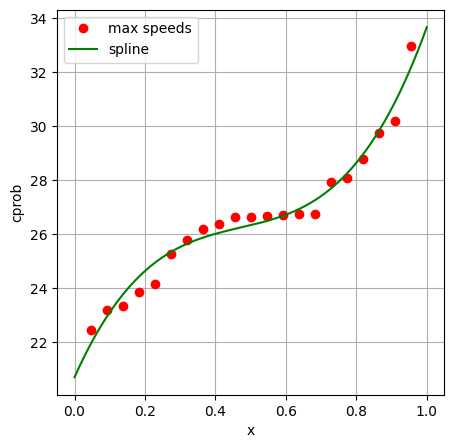

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline as us

max_speeds = np.load('max-speeds.npy')
max_speeds.sort()
print(max_speeds)
#years_nb = max_speeds.shape[0]


cprob = np.array([i/22 for i in range(1,22)])
print(cprob)

x =np.arange(1,22)
xs = np.linspace(0,1, 1000)
print(x)

m = us(cprob, max_speeds)

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(cprob, max_speeds, 'o', c='r', label = 'max speeds') #max_speeds vs cprob
ax.plot(xs, m(xs), 'g-', label = 'spline')
ax.grid()
ax.set_xlabel('x')
ax.set_ylabel('cprob')
ax.legend()

fifty_prob = 1. - 0.02
fifty_wind = m(fifty_prob)
print(fifty_wind)

[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]
[0.04545455 0.09090909 0.13636364 0.18181818 0.22727273 0.27272727
 0.31818182 0.36363636 0.40909091 0.45454545 0.5        0.54545455
 0.59090909 0.63636364 0.68181818 0.72727273 0.77272727 0.81818182
 0.86363636 0.90909091 0.95454545]
32.97989844019469


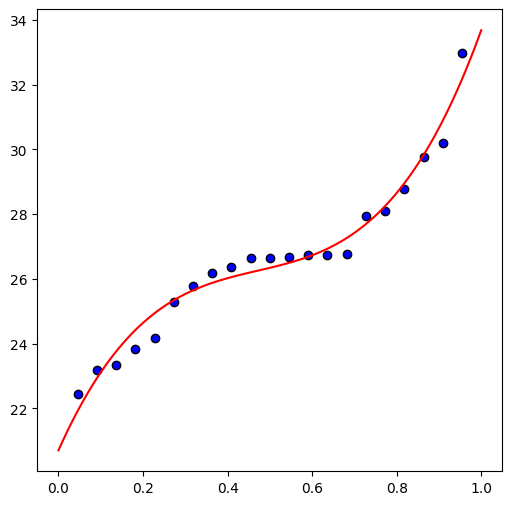

In [54]:
import numpy as np
from scipy.interpolate import UnivariateSpline as usp
import matplotlib.pyplot as plt

max_speeds = np.load('max-speeds.npy')
max_speeds.sort()
print(max_speeds)
years_nb = max_speeds.shape[0]

cprob = np.array([i/22 for i in range(1,22)])
print(cprob)

quant_func = usp(cprob, max_speeds)
x = np.linspace(0, 1, 100)
quant = quant_func(x)
fig , ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(cprob, max_speeds, color = 'blue', edgecolor = 'black')
ax.plot(x, quant, 'r')

fifty_prob = 1. - 0.02
fifty_wind = quant_func(fifty_prob)
print(fifty_wind)

[22.46 23.2  23.34 23.85 24.16 25.28 25.79 26.19 26.37 26.65 26.65 26.68
 26.73 26.75 26.76 27.93 28.09 28.79 29.75 30.19 32.97]
[0.045454545454545456, 0.09090909090909091, 0.13636363636363635, 0.18181818181818182, 0.22727272727272727, 0.2727272727272727, 0.3181818181818182, 0.36363636363636365, 0.4090909090909091, 0.45454545454545453, 0.5, 0.5454545454545454, 0.5909090909090909, 0.6363636363636364, 0.6818181818181818, 0.7272727272727273, 0.7727272727272727, 0.8181818181818182, 0.8636363636363636, 0.9090909090909091, 0.9545454545454546]
32.97989844019469


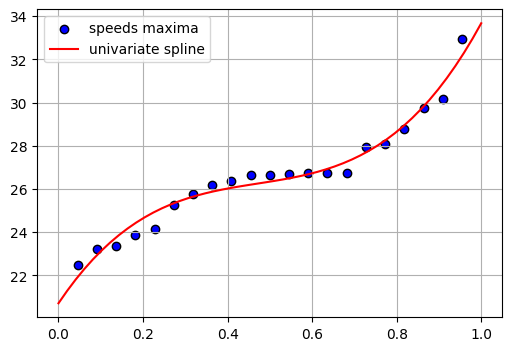

In [2]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline as usp
    
max_speeds = np.load('max-speeds.npy')
max_speeds.sort()
print(max_speeds)
years_nb = max_speeds.shape[0]
cprob = []
for i in range(1, 22):
    cprob.append(i/22)
print(cprob)
fig, ax = plt.subplots(figsize = (6,4))
ax.scatter(x = cprob, y = max_speeds, color = 'blue', edgecolor = "black", label = 'speeds maxima')
ax.grid(True)

quantile_function = usp(cprob, max_speeds) 
intervals = np.linspace(0, 1, 50)
quantile = quantile_function(intervals)
ax.plot(intervals, quantile, c='r', label='univariate spline')
ax.legend(loc = 'best')
fifty_prob = 1. - 0.02
fifty_wind = quantile_function(fifty_prob)
print(fifty_wind)

2\. **Curve fitting of temperature in Alaska** 

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[ns]', freq='MS')
0.1415829651365931


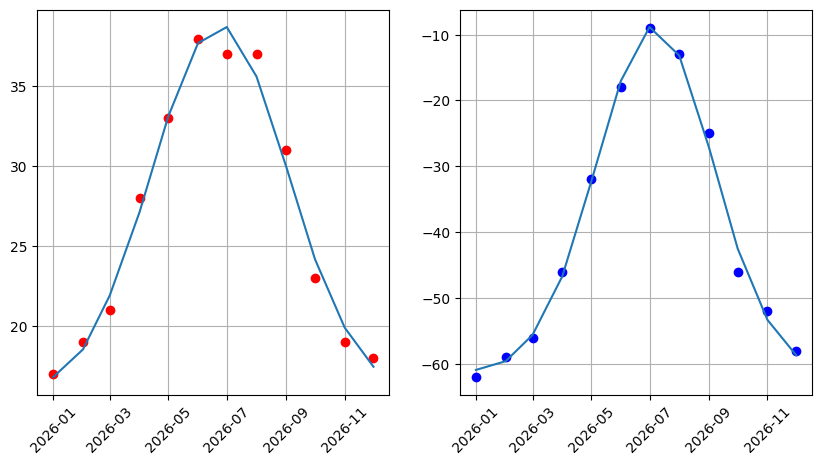

In [51]:
import pandas as pd
import numpy as np
from scipy import optimize

def f(x, A, mu, sigma, c) :
    return A*np.exp(-(x-mu)**2/(2*sigma**2)) + c

months = pd.date_range('01/01/2026', periods=12, freq='MS')
print(months)

maxi = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
mini = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
x_data = np.arange(1,13)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.plot(months, maxi, 'o', c= 'r')
ax1.tick_params(axis= 'x', rotation= 45) #per ruotare i ticks!!
ax2.plot(months, mini, 'o', c= 'b')
ax2.tick_params(axis = 'x', rotation= 45)
ax1.grid()
ax2.grid()

maxi_params, maxi_cov = optimize.curve_fit(f, x_data, maxi, p0=[2, 6, 2, 30])
mini_params, mini_cov = optimize.curve_fit(f, x_data, mini, p0=[2, 6, 2, 30])

ax1.plot(months, f(x_data, maxi_params[0], maxi_params[1], maxi_params[2], maxi_params[3])) #metto comunque months nelle x!!
ax2.plot(months, f(x_data, mini_params[0], mini_params[1], mini_params[2], mini_params[3]))

test = np.abs( maxi_params[1]- mini_params[1])/np.sqrt(mini_params[2]**2+maxi_params[2]**2)
print(test) # test < 1, the means are the same within fit accuracy

DatetimeIndex(['2025-12-31', '2026-01-31', '2026-02-28', '2026-03-31',
               '2026-04-30', '2026-05-31', '2026-06-30', '2026-07-31',
               '2026-08-31', '2026-09-30', '2026-10-31', '2026-11-30'],
              dtype='datetime64[ns]', freq='M')
[23.09207412  6.73581572  2.29443237 15.77934045]
[[ 1.32866334e+00 -1.60419654e-03  1.01478558e-01 -1.08339438e+00]
 [-1.60419654e-03  6.31513757e-03 -2.12228167e-04  1.91643577e-03]
 [ 1.01478558e-01 -2.12228167e-04  2.75438680e-02 -1.70933214e-01]
 [-1.08339438e+00  1.91643577e-03 -1.70933214e-01  1.38431934e+00]]
[ 52.6492929    7.16452587   1.97590034 -61.32093885]
[[ 1.96936978e+00 -8.73532605e-04  2.27194231e-02 -1.05131685e+00]
 [-8.73532605e-04  2.22850502e-03 -4.92569596e-05  1.09105206e-03]
 [ 2.27194231e-02 -4.92569596e-05  5.77332810e-03 -7.06528876e-02]
 [-1.05131685e+00  1.09105206e-03 -7.06528876e-02  1.41332367e+00]]
0.14158335526890764


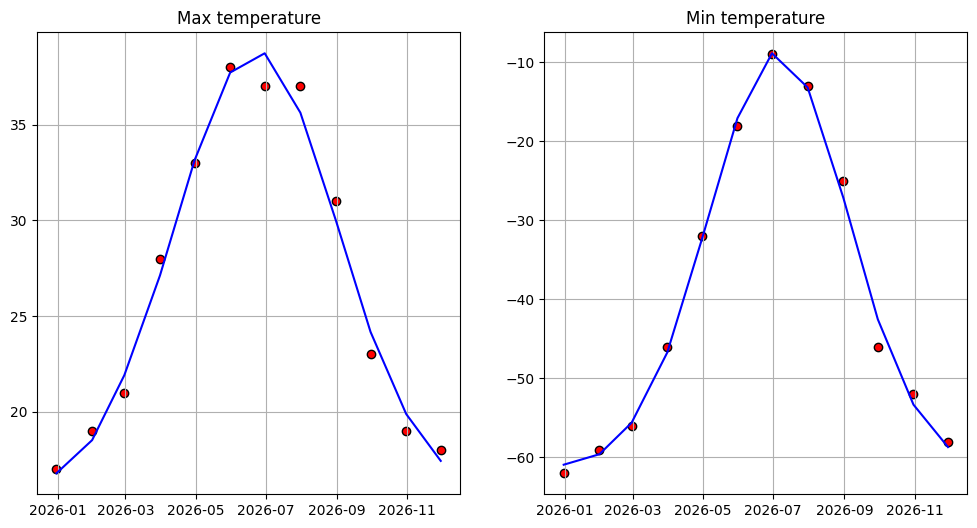

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
import pandas as pd

def func(x, A, mu, sigma, shift):
    f = A*np.exp(-((x-mu)**2)/(2*sigma**2)) + shift
    return f
    
date = 'Dec 2025'
months = pd.date_range(date, periods=12, freq='M')
print(months)
maxi = [17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18]
mini = [-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6))
ax1.scatter(months, maxi, color = 'r', edgecolor = 'black')
ax1.set_title('Max temperature')
ax2.scatter(months, mini, color = 'r', edgecolor = 'black')
ax2.set_title('Min temperature')
ax1.grid(True)
ax2.grid(True)

months_num = np.arange(1,13)
params_max, params_covariance_max = optimize.curve_fit(func, months_num, maxi, p0=[20, 7, 2, 30])
print(params_max)
print (params_covariance_max)

params_min, params_covariance_min = optimize.curve_fit(func, months_num, mini, p0=[20, 7, 2, 30])
print(params_min)
print (params_covariance_min)

x = np.arange(1, 13)
inter_max = func(x, params_max[0], params_max[1], params_max[2], params_max[3])
ax1.plot(months, inter_max, color = 'blue')
inter_min = func(x, params_min[0], params_min[1], params_min[2], params_min[3])
ax2.plot(months, inter_min, color = 'blue')

test = np.abs(params_max[1]-params_min[1])/np.sqrt(params_max[2]**2+params_min[2]**2)
print(test)

[23.09209914  6.73581695  2.29443922 15.77929812] 
 [[ 1.32856378e+00 -1.60381406e-03  1.01462817e-01 -1.08326592e+00]
 [-1.60381406e-03  6.31509454e-03 -2.12180966e-04  1.91599824e-03]
 [ 1.01462817e-01 -2.12180966e-04  2.75415745e-02 -1.70914950e-01]
 [-1.08326592e+00  1.91599824e-03 -1.70914950e-01  1.38416916e+00]]
[ 52.6492923    7.16452594   1.9759002  -61.32093711] 
 [[ 1.32856378e+00 -1.60381406e-03  1.01462817e-01 -1.08326592e+00]
 [-1.60381406e-03  6.31509454e-03 -2.12180966e-04  1.91599824e-03]
 [ 1.01462817e-01 -2.12180966e-04  2.75415745e-02 -1.70914950e-01]
 [-1.08326592e+00  1.91599824e-03 -1.70914950e-01  1.38416916e+00]]
0.14158273410049205


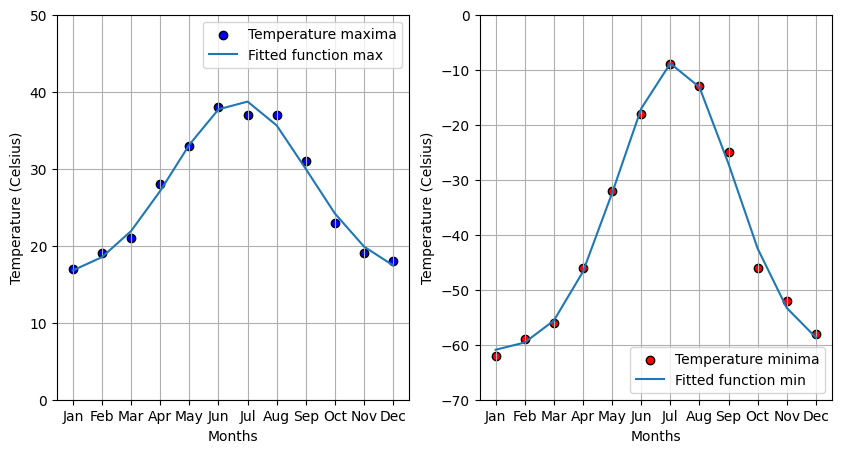

In [3]:
from scipy import optimize as opt
import math
import pandas as pd

def f(x, A, mu, sigma, shift):
    return A*np.exp(-0.5 * ((x - mu) / sigma)**2) + shift

maxi = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
mini = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
months = np.array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
#months = pd.date_range(start='2026-01-01', periods=12, freq='MS').strftime('%b').to_list()
n_month = np.arange(1, 13)

fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(10,5))
ax1.scatter(x = months, y = maxi, color = 'blue', edgecolor= 'black', label = 'Temperature maxima')
ax2.scatter(x = months, y = mini, color = 'red', edgecolor= 'black', label = 'Temperature minima')
ax1.grid(True)
ax1.set_xlabel('Months')
ax1.set_ylabel('Temperature (Celsius)')
ax1.set_ylim(0,50)
ax2.grid(True)
ax2.set_xlabel('Months')
ax2.set_ylabel('Temperature (Celsius)')
ax2.set_ylim(-70,0)

params_max, cov_max = opt.curve_fit(f, n_month, maxi, p0=[25, 6, 2, 20])
print(params_max, "\n", cov_max)
params_min, cov_min = opt.curve_fit(f, n_month, mini, p0=[40, 6, 2, -8])
print(params_min, "\n", cov_max)

ax1.plot(months, f(n_month, params_max[0], params_max[1], params_max[2], params_max[3]), label='Fitted function max')
ax2.plot(months, f(n_month, params_min[0], params_min[1], params_min[2], params_min[3]), label='Fitted function min')
ax1.legend(loc = 'best')
ax2.legend(loc = 'best')

test = abs(params_max[1]-params_min[1])/np.sqrt(params_max[2]**2+params_min[2]**2)
print(test) # the two means are compatible within 1 sigma

3\. **2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 2.104250310311354
        x: [-1.607e+00 -5.687e-01]
      nit: 7
      jac: [ 1.465e-06  8.882e-08]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -1.0316284534898772
        x: [ 8.984e-02 -7.127e-01]
      nit: 6
      jac: [ 2.220e-08  2.220e-08]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -1.031628453489877
        x: [-8.984e-02  7.127e-01]
      nit: 4
      jac: [-2.220e-08  0.000e+00]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 2.104250310311377
        x: [ 1.607e+00  5.6

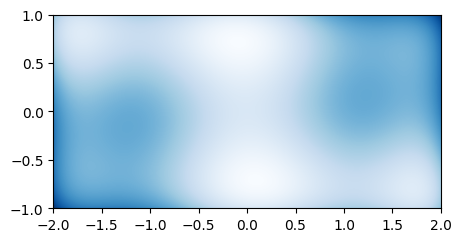

In [55]:
from scipy import optimize as sco
def f(m):
    (x, y) = m
    return (4-2.1*x**2+x**4/3)*x**2+x*y+(4*y**2-4)*y**2

x = np.linspace(-2,2,1000)
y  = np.linspace(-1,1,1000)


xx, yy = np.meshgrid(x,y)
z = f((xx, yy))

fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.imshow(z, cmap = 'Blues', origin = 'lower', extent=[-2, 2, -1, 1]) #extente importantissimo!!
#res = minimize(fun, (2, 0), method='SLSQP', bounds=bnds, constraints=cons)
min1 = sco.minimize(f, x0 = (-1.75, -0.75), bounds=((-2, -1.5),(-1, -0.5))) #vanno bene tutte parentesi tonde!!
print(min1)
min2 = sco.minimize(f, x0 = (-0.75, 0), bounds=((-0.5, 0.5),(-1, -0.5)))
print(min2)
min3 = sco.minimize(f, x0 = (0, 0.75), bounds=[[-0.5, 0.5],[0.5, 1]])
print(min3)
min4 = sco.minimize(f, x0 = (1.75, 0.75), bounds=[[1.5, 2],[0.5, 1]])
print(min4)
min5 = sco.minimize(f, x0 = (0,0), bounds=[[-0.5, 0.5],[-0.5, 0.5]])
print(min5)

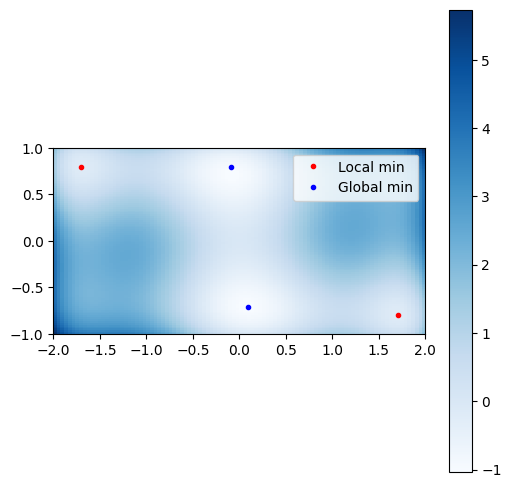

In [39]:
import numpy as np
import scipy.optimize as sco

def f(var):
    x, y = var
    return (4 - 2.1*x**2 + (x**4)/3)*x**2 + x*y + (4*y**2 - 4)*y**2

x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 1, 100)
var = np.meshgrid(x, y)
z = f(var)

fig, ax = plt.subplots(1,1, figsize = (6,6))
pos = ax.imshow(z, cmap='Blues', interpolation='none', origin = 'lower', extent = (-2,2,-1,1))
ax.set_xlim(-2,2)
ax.set_ylim(-1,1)
fig.colorbar(pos, ax=ax)

min_1 = optimize.minimize(f, x0 = (-1.75, 0.75), bounds=[[-2, -1.5],[0.5,1]])
min_2 = optimize.minimize(f, x0 = (0, 0.75), bounds=[[-0.5, 0.5],[0.25,1]])
min_3 = optimize.minimize(f, x0 = (0, -0.75), bounds=[[-0.5, 0.5],[-1,-0.5]])
min_4 = optimize.minimize(f, x0 = (1.75, -0.75), bounds=[[1.5, 2],[-1, -0.5]])

ax.plot(min_1.x[0], min_1.x[1], 'o', markersize = 3, color = 'r', label = 'Local min')
ax.plot(min_2.x[0], min_1.x[1], 'o', markersize = 3, color = 'b', label = 'Global min')
ax.plot(min_3.x[0], min_3.x[1], 'o', markersize = 3, color = 'b')
ax.plot(min_4.x[0], min_4.x[1], 'o', markersize = 3, color = 'r')

ax.legend(loc = 'best')



(100, 100)
[  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -0.21546382438293066
        x: [-1.704e+00  7.961e-01]
      nit: 5
      jac: [ 1.843e-06 -5.407e-06]
     nfev: 21
     njev: 7
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>,   message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -1.0316284534898124
        x: [-8.984e-02  7.127e-01]
      nit: 5
      jac: [ 1.021e-06 -8.882e-08]
     nfev: 21
     njev: 7
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>,   message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -1.0316284534898066
        x: [ 8.984e-02 -7.127e-01]
      nit: 5
      jac: [-1.021e-06  8.882e-08]
     nfev: 21
     njev: 7
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>,   message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: -0.21546382438293854
     

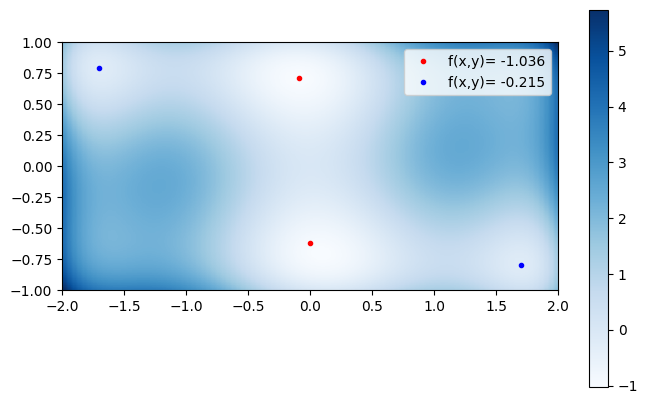

In [45]:
import scipy.optimize as optimize

def f(variables):
    x, y = variables
    return (4-2.1*x**2+(x**4)/3)*x**2+x*y+(4*y**2-4)*y**2
def hessian(n):
    x, y = n
    f_xx = 12*x**2 - 12.6*x**2 + 4*x**4 + 2
    f_yy = 48*y**2 - 8
    f_xy = 1
    return np.array([[f_xx, f_xy],
                     [f_xy, f_yy]])    

x1 = np.linspace(-2, 2, 100)
y1 = 0
x2 = 0 
y2 = np.linspace(-1, 1, 100)
var = np.meshgrid(x1, y2)
func = f(var)
print(func.shape)

fig, imag = plt.subplots(nrows = 1, ncols = 1, figsize = (8,7))
pos = imag.imshow(func, origin='lower', interpolation = None, extent =(-2, 2, -1, 1), cmap='Blues')
fig.colorbar(pos, ax=imag, anchor=(0, 0.3), shrink=0.7)
imag.set_xlim(-2,2)
imag.set_ylim(-1,1)

x = [(-1.75, 0.75), (0 , 0.75), (0 , -0.75), (1.75, -0.75)]
bound = [[[-2, -1],[0.5, 1]], [[-0.5, 0.5],[0.25, 1]], [[-0.5, 0.5],[-1, -0.25]], [[1, 2],[-1, -0.5]]]
mini = []
for i in range(4):
    mini.append(optimize.minimize(fun = f, x0 = x[i], bounds = bound[i], method = 'L-BFGS-B'))
print(mini)
idx = np.argmin([minis.fun for minis in mini])
sol = mini[idx].fun
print(sol)
zero = optimize.minimize(fun = f, x0 = (0,0), bounds = [[-0.5, 0.5], [-0.5,0.5]], method = 'L-BFGS-B')
print("zero:\n", zero)

eig= np.array([np.linalg.eigvals(hessian(i.x)) for i in mini])
print(eig)
imag.plot(-0.08984 , 0.7127, 'ro', markersize=3, label= 'f(x,y)= -1.036')
imag.plot(0.08984 -0.7127, 'ro', markersize=3)
imag.plot(-1.704,  0.7961, 'bo', markersize=3, label= 'f(x,y)= -0.215')
imag.plot(1.704, -0.7961, 'bo', markersize = 3)
imag.legend()
plt.show()

4\. **FFT of a simple dataset**

Performe a periodicity analysis on the lynxs-hares population

0.09523809523809523 10.5
0.09523809523809523 10.5


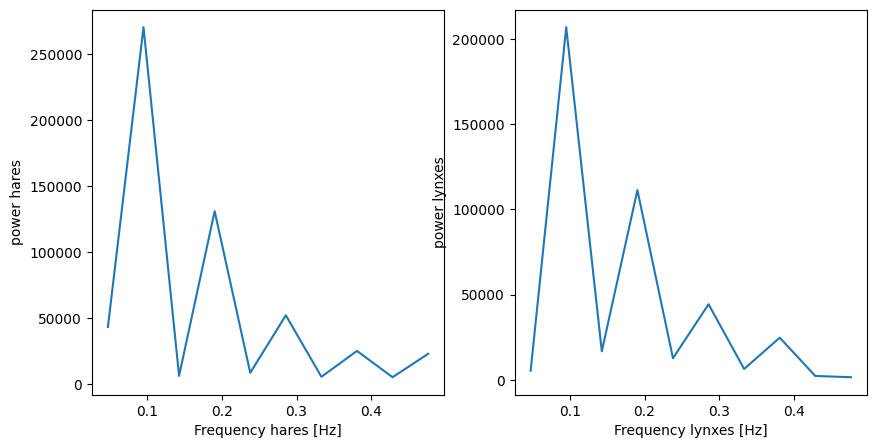

In [149]:
import scipy.fftpack as fftpack

pop = np.loadtxt('populations.txt')
pop
years = pop[:, 0]
lynxes = pop[:, 2]
hares = pop[:, 1]
time_step = 1

sig_fft_l = fftpack.fft(lynxes) # 1 fft
sample_freq_l = fftpack.fftfreq(lynxes.size, d=time_step) # 2 fftfreq
pos_mask_l = np.where(sample_freq_l > 0) # freq>0
sample_freq_l = sample_freq_l[pos_mask_l] 
power_l = np.abs(sig_fft_l)[pos_mask_l] # power for freq>0

sig_fft_h = fftpack.fft(hares)
sample_freq_h = fftpack.fftfreq(hares.size, d=time_step)
pos_mask_h = np.where(sample_freq_h > 0)
sample_freq_h = sample_freq_h[pos_mask_h]
power_h = np.abs(sig_fft_h)[pos_mask_h]

peak_freq_l = sample_freq_l[power_l.argmax()] # power argmax
print(peak_freq_l, 1/peak_freq_l)
peak_freq_h = sample_freq_h[power_h.argmax()]
print(peak_freq_h, 1/peak_freq_h)


# Plot the FFT power
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))
ax1.plot(sample_freq_h, power_h)
ax1.set_xlabel('Frequency hares [Hz]')
ax1.set_ylabel('power hares')
ax2.plot(sample_freq_l, power_l)
ax2.set_xlabel('Frequency lynxes [Hz]')
ax2.set_ylabel('power lynxes')
plt.show()

0.09523809523809523
Period:  10.5
0.09523809523809523
Period:  10.5


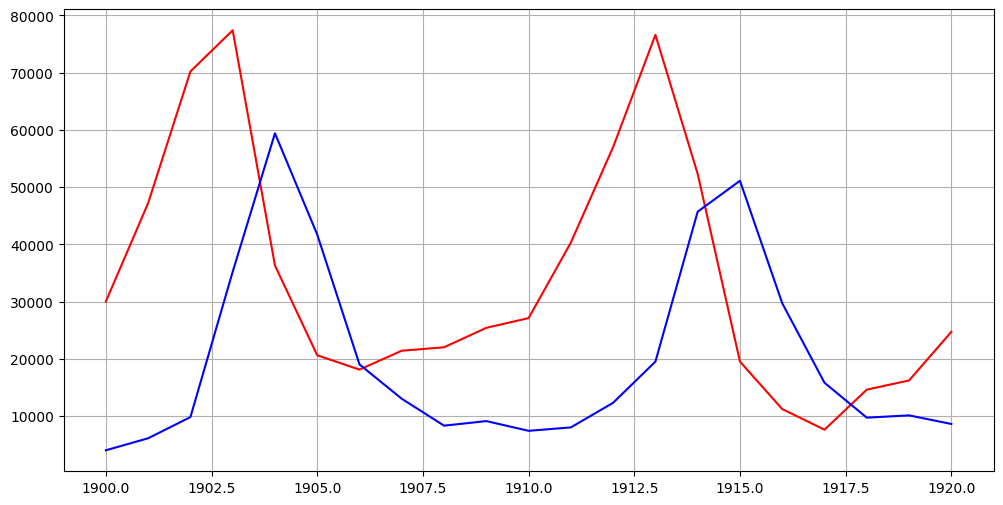

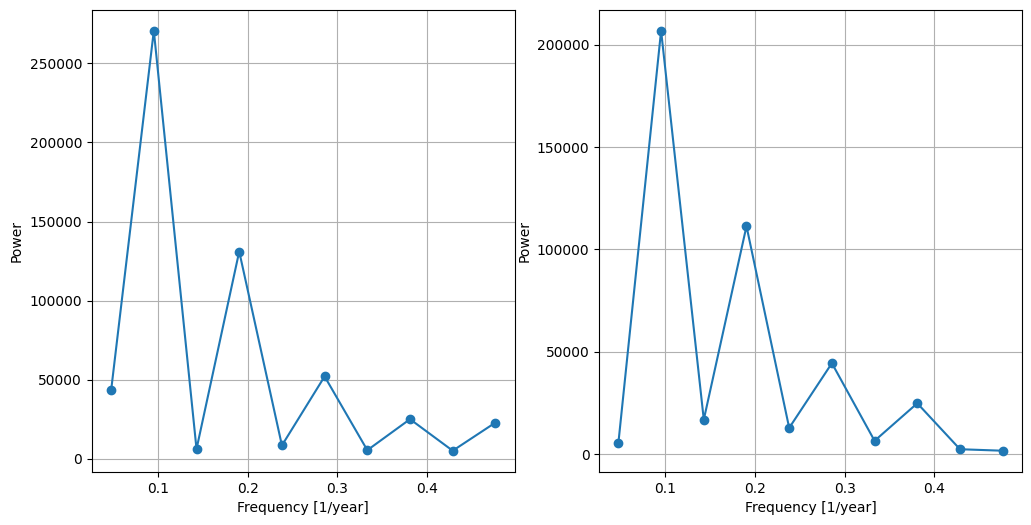

In [27]:
import numpy as np
from scipy import fftpack
from matplotlib import pyplot as plt

m = np.loadtxt('populations.txt')
hares = m[: , 1]
linxes = m[: , 2]
years = m[: , 0]

fig, ax = plt.subplots(1, 1, figsize = (12,6))
ax.plot(years, hares, color = 'r')
ax.plot(years, linxes, color = 'b')
ax.grid(True)

time_step = 1
sample_freq_h = fftpack.fftfreq(hares.size, d=time_step)
sig_fft_h = fftpack.fft(hares)
power_h = np.abs(sig_fft_h)[sample_freq_h > 0]
peak_freq_h = sample_freq_h[sample_freq_h > 0][power_h.argmax()]
print(peak_freq_h)
print("Period: ", 1/peak_freq_h)

sample_freq_l = fftpack.fftfreq(linxes.size, d=time_step)
sig_fft_l = fftpack.fft(linxes)
power_l = np.abs(sig_fft_l)[sample_freq_l > 0]
peak_freq_l = sample_freq_l[sample_freq_l > 0][power_l.argmax()]
print(peak_freq_l)
print("Period: ", 1/peak_freq_l)

fig, (axh, axl) = plt.subplots(1, 2, figsize = (12, 6))

axh.plot(sample_freq_h[sample_freq_h>0], power_h, 'o-')
axh.set_xlabel('Frequency [1/year]')
axh.set_ylabel('Power')
axh.grid(True)

axl.plot(sample_freq_l[sample_freq_l>0], power_l, 'o-')
axl.set_xlabel('Frequency [1/year]')
axl.set_ylabel('Power')
axl.grid(True)

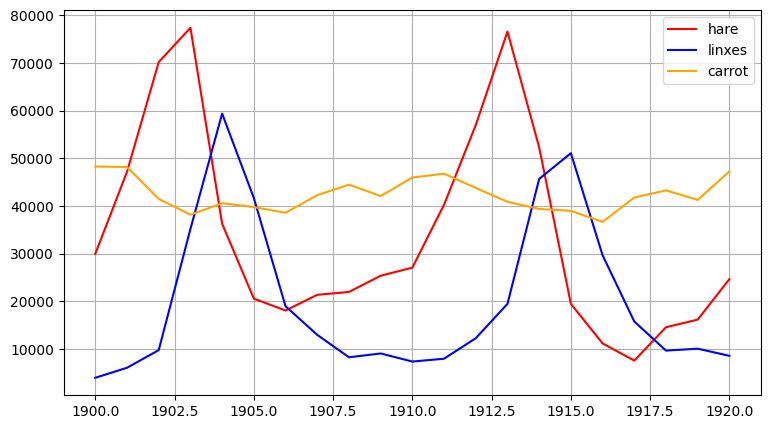

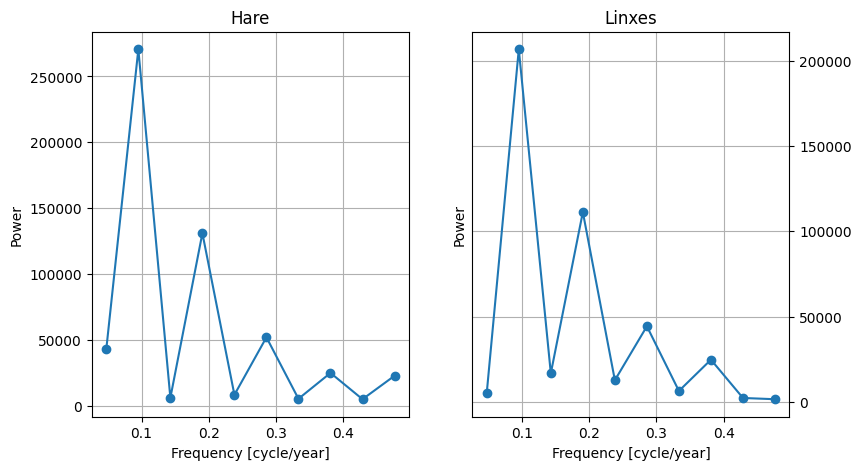

10.5
10.5


/home/elena/.local/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


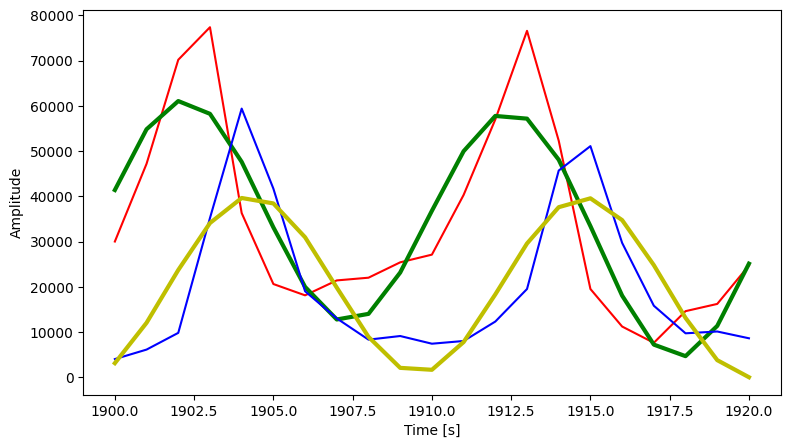

In [3]:
from scipy import fftpack

m = np.loadtxt('populations.txt')
years = m[:,0]
hare = m[:,1]
linxes = m[:,2]
carrot = m[:,3]

fig1, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(9,5))
ax.plot(years, hare, 'r', label = 'hare')
ax.plot(years, linxes, 'b', label = 'linxes')
ax.plot(years, carrot, 'orange', label = 'carrot')
ax.grid(True)
ax.legend()
plt.show()

hare_freq = fftpack.fftfreq(hare.size, d=1)
hare_fft = fftpack.fft(hare)
hare_power = np.abs(hare_fft)[hare_freq > 0]

linxes_freq = fftpack.fftfreq(linxes.size, d=1)
linxes_fft = fftpack.fft(linxes)
linxes_power = np.abs(linxes_fft)[linxes_freq > 0]
# The corresponding frequencies
# Plot the FFT power

fig2, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (9,5))
ax1.plot(hare_freq[hare_freq > 0], hare_power, 'o-')
ax2.plot(linxes_freq[linxes_freq > 0], linxes_power, 'o-')
ax1.set_xlabel('Frequency [cycle/year]')
ax1.set_ylabel('Power')
ax1.set_title('Hare')
ax2.set_xlabel('Frequency [cycle/year]')
ax2.set_ylabel('Power')
ax2.set_title('Linxes')
ax1.grid(True)
ax2.grid(True)
ax2.yaxis.tick_right()
plt.show()

hare_freqs = hare_freq[hare_freq>0]
hare_peak_freq = hare_freqs[hare_power.argmax()]
high_hare_fft = hare_fft.copy()
high_hare_fft[np.abs(hare_freq) > hare_peak_freq] = 0
filtered_sig_hare = fftpack.ifft(high_hare_fft)

linxes_freqs = linxes_freq[linxes_freq>0]
linxes_peak_freq = linxes_freqs[linxes_power.argmax()]
high_linxes_fft = linxes_fft.copy()
high_linxes_fft[np.abs(linxes_freq) > linxes_peak_freq] = 0
filtered_sig_linxes = fftpack.ifft(high_linxes_fft)

fig3, ax = plt.subplots(nrows = 1, ncols = 1, figsize= (9,5))
ax.plot(years, hare, 'r')
ax.plot(years, filtered_sig_hare, 'g', linewidth=3)
ax.plot(years, linxes, 'b')
ax.plot(years, filtered_sig_linxes,'y', linewidth=3)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')

print(1/hare_peak_freq)
print(1/linxes_peak_freq)

5\. **FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

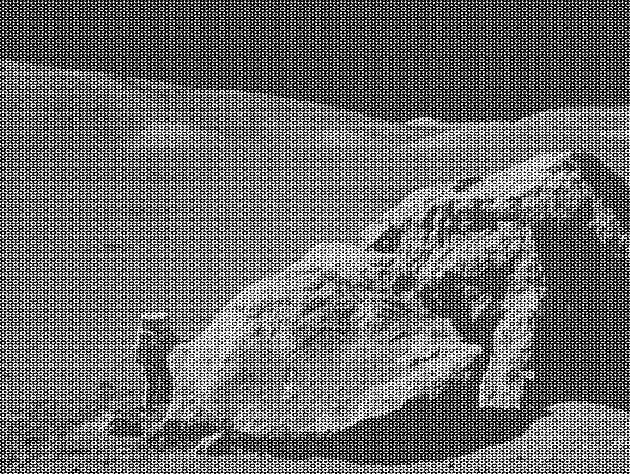

In [6]:
from IPython.display import Image
Image("moonlanding.png")

[[0.28215325 0.31723544 0.34800664 ... 0.254416   0.24546337 0.25528455]
 [0.29741022 0.34325126 0.37722203 ... 0.25093314 0.2410132  0.25824192]
 [0.31558374 0.3516624  0.37676963 ... 0.27123246 0.26674244 0.2831354 ]
 ...
 [0.41191915 0.3471331  0.3163537  ... 0.52302426 0.52453464 0.4815076 ]
 [0.34341875 0.3147688  0.30876642 ... 0.39523745 0.39900148 0.3779487 ]
 [0.29450145 0.3022329  0.31859744 ... 0.29978347 0.29759288 0.29439676]]


/tmp/ipykernel_18552/1918875579.py:16: RuntimeWarning: divide by zero encountered in log
  ax[1,1].imshow(np.log(power_new))


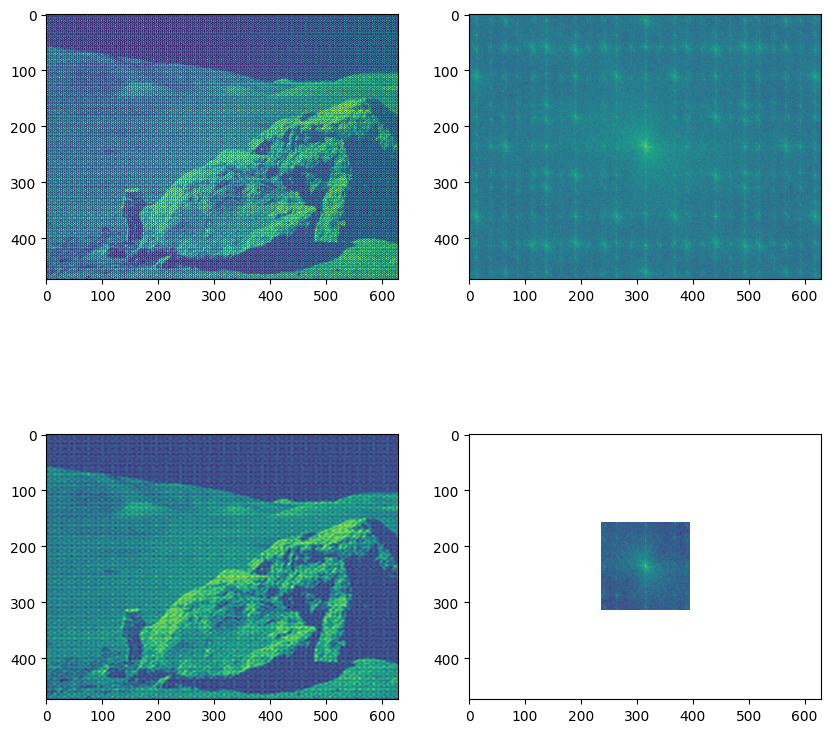

In [49]:
import scipy.fftpack as fftpack

m = plt.imread('moonlanding.png')
fft = fftpack.fftshift(fftpack.fft2(m)) #fftshift importante!!
power = np.abs(fft)
fig, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].imshow(m)
ax[0,1].imshow(np.log(power)) # log of power!!

col, row = m.shape
coll, roww = col//2, row//2
sel = 80
fft_new = np.zeros_like(fft) # create a new fft, in this way it will have the same dimension, otherwise the i
fft_new[coll-sel : coll+sel, roww-sel : roww+sel] = fft[coll-sel : coll+sel, roww-sel : roww+sel]
power_new = np.abs(fft_new)
ax[1,1].imshow(np.log(power_new))

new_image = np.real(fftpack.ifft2(fftpack.fftshift(fft_new))) #np.real importante!!
print(new_image)
ax[1,0].imshow(new_image)

(474, 630)
(298620,)


/tmp/ipykernel_7118/2885696497.py:24: RuntimeWarning: divide by zero encountered in log
  ax[1][1].imshow(np.log(new_power))


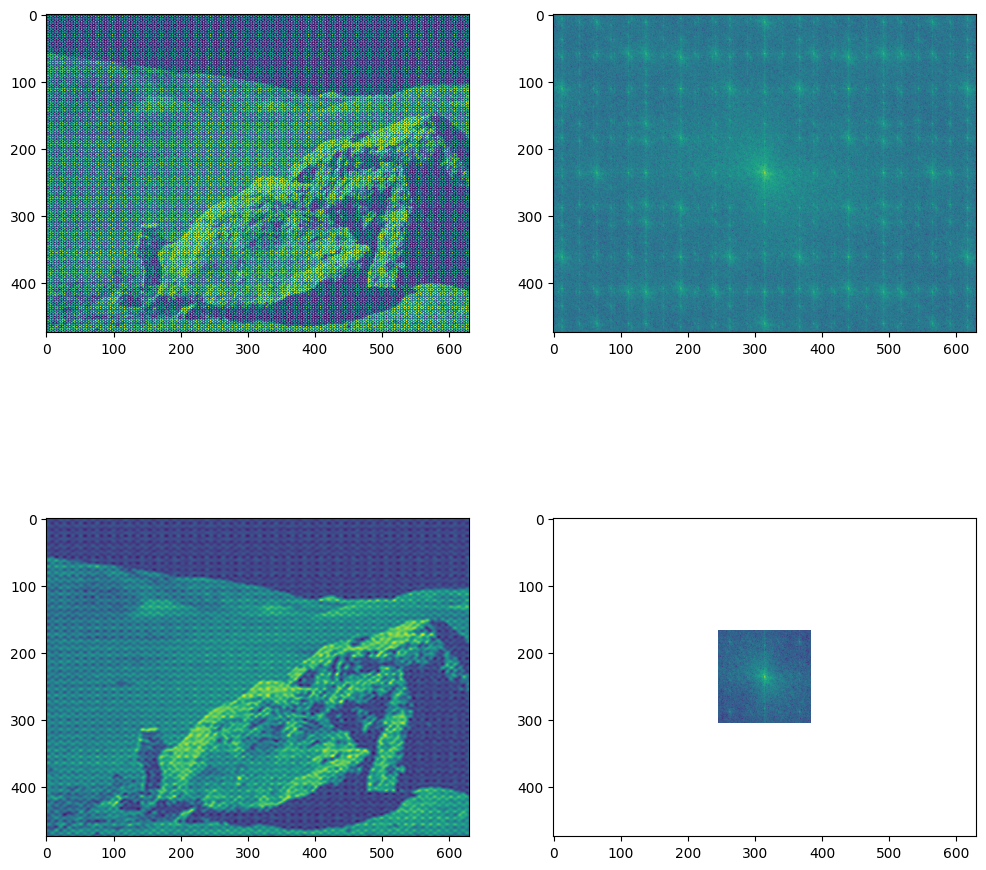

In [51]:
import matplotlib.pyplot as plt
import scipy.fftpack as fftpack

m = plt.imread("moonlanding.png")
print(m.shape)
fft = fftpack.fftshift(fftpack.fft2(m))
power = np.abs(fft)
time_step = 0.02
freq = fftpack.fftfreq(m.size, d=time_step)
print(freq.shape)

fig , ax = plt.subplots(2,2,figsize = (12,12))
ax[0][0].imshow(m)
ax[0][1].imshow(np.log(power))

col, row = m.shape
colm, rowm = col//2, row//2
sel = 70
new_fft = np.zeros_like(fft)
new_fft[colm-sel:colm+sel, rowm-sel:rowm+sel]=fft[colm-sel:colm+sel, rowm-sel:rowm+sel]
new_power = np.abs(new_fft)
new_m = np.real(fftpack.ifft2(fftpack.fftshift(new_fft)))
ax[1][0].imshow(new_m)
ax[1][1].imshow(np.log(new_power))

In [12]:
from IPython.display import Image
Image("moonlanding.png")

/tmp/ipykernel_282/2991114096.py:26: RuntimeWarning: divide by zero encountered in log
  ax[1][1].imshow(np.log(newmoonpower), cmap='gray')


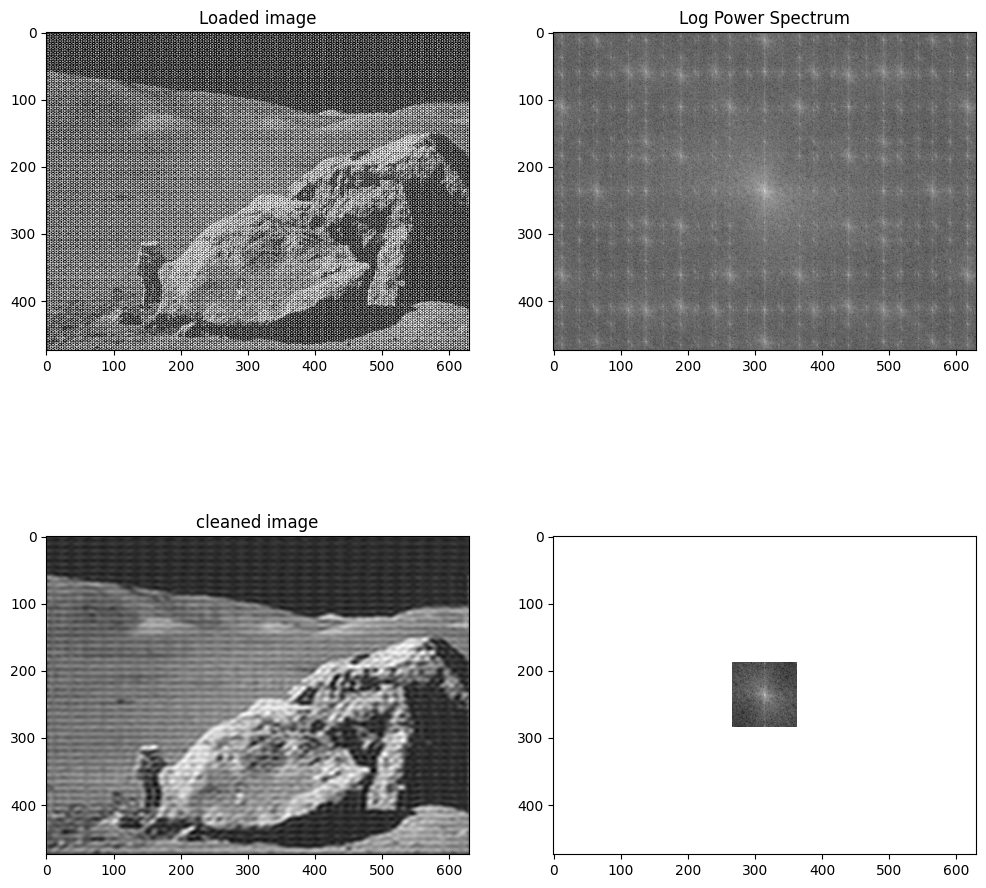

In [40]:
image = plt.imread('moonlanding.png', format = 'png')

image_fft = fftpack.fftshift(fftpack.fft2(image)) #shift the frequence (0,0) in the center
image_power = np.abs(image_fft)

rows, cols = image.shape
c_row, c_col = rows//2, cols//2 #This returns the certer row and the center column
newmoonfft = np.zeros_like(image_fft)
sel=50
newmoonfft[c_row-sel : c_row+sel, c_col-sel : c_col+sel] = image_fft[c_row-sel : c_row+sel, c_col-sel : c_col+sel]
newmoonpower = np.abs(newmoonfft)
newmoonimage = np.real(fftpack.ifft2(fftpack.fftshift(newmoonfft)))

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

#plot of the original image
ax[0][0].imshow(image, cmap='gray')
ax[0][0].set_title("Loaded image")
ax[0][1].imshow(np.log(image_power), cmap='gray')
ax[0][1].set_title("Log Power Spectrum")

#plot of the cleaned image
ax[1][0].imshow(newmoonimage, cmap='gray')
ax[1][0].set_title("cleaned image")
#ax[1][1].imshow(np.log(image_power+1), cmap='gray')
ax[1][1].imshow(np.log(newmoonpower), cmap='gray')